### Задание 1. Загрузка и профилирование данных

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Загрузка данных
df = pd.read_csv('C:\\Users\\му-рс\\OneDrive\\Рабочий стол\\lab2\\data\\bmw.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов [cite: 1, 2]')
df.head()

Размер датасета: 10781 строк, 9 столбцов [cite: 1, 2]


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [8]:
# Информация о типах данных и пропусках
print("Информация о датасете")
df.info()

# Статистика по числовым признакам
print("\nОписательная статистика")
display(df.describe())

# Проверка на наличие пропусков
print("\nАнализ пропусков")
print(df.isnull().sum())

Информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB

Описательная статистика


,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000



Анализ пропусков
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


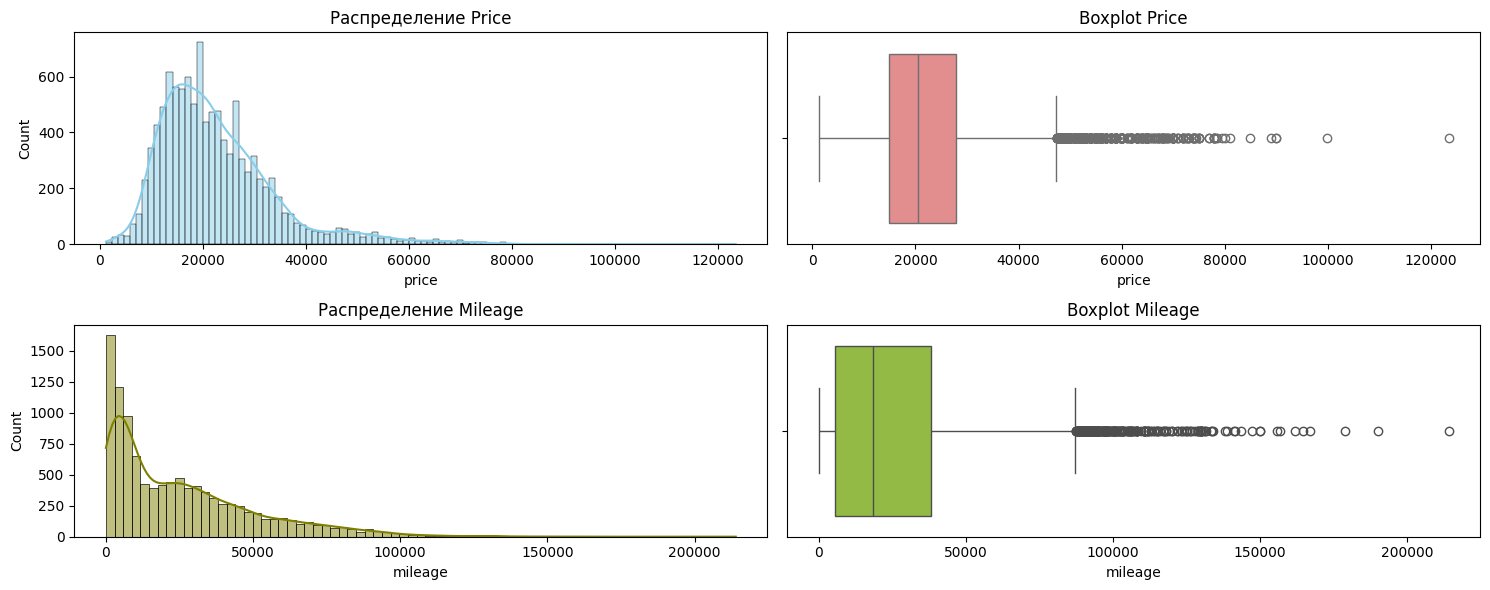

In [9]:
# Настройка визуализации
plt.figure(figsize=(15, 6))

# Гистограмма и Boxplot для Price
plt.subplot(2, 2, 1)
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Распределение Price')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['price'], color='lightcoral')
plt.title('Boxplot Price')

# Гистограмма и Boxplot для Mileage
plt.subplot(2, 2, 3)
sns.histplot(df['mileage'], kde=True, color='olive')
plt.title('Распределение Mileage')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['mileage'], color='yellowgreen')
plt.title('Boxplot Mileage')

plt.tight_layout()
plt.show()

### Задание 2. Проверка нормальности распределения

In [32]:
features = ['price', 'mileage']

for col in features:
    print(f"\nАнализ признака: {col}")
    
    # Характеристики
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()
    
    print(f"Среднее: {mean_val:.2f}")
    print(f"Медиана: {median_val:.2f}")
    print(f"Коэффициент асимметрии: {skew_val:.2f}")
    print(f"Коэффициент эксцесса: {kurt_val:.2f}") 
    



Анализ признака: price
Среднее: 22733.41
Медиана: 20462.00
Коэффициент асимметрии: 1.59
Коэффициент эксцесса: 4.02

Анализ признака: mileage
Среднее: 25496.99
Медиана: 18347.00
Коэффициент асимметрии: 1.38
Коэффициент эксцесса: 2.23


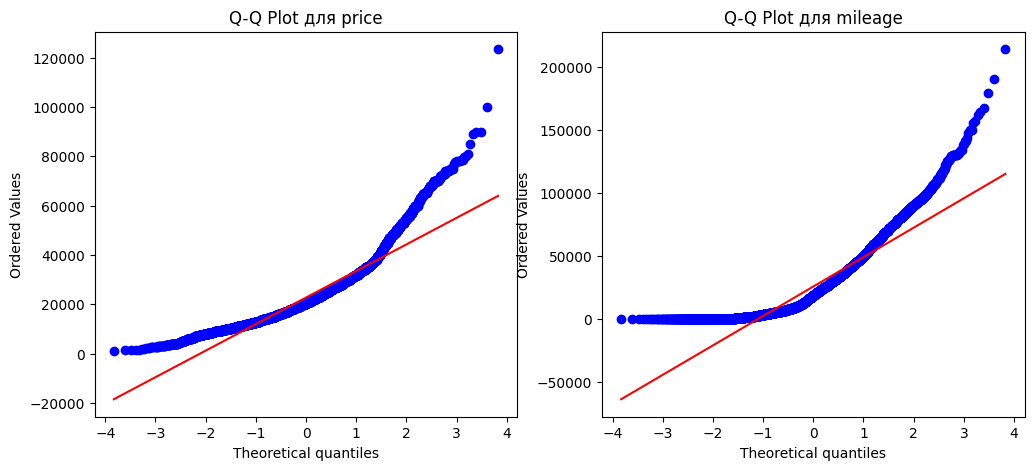

In [13]:
plt.figure(figsize=(12, 5))

for i, col in enumerate(features, 1):
    plt.subplot(1, 2, i)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot для {col}')

plt.show()

Вывод: Распределения не являются нормальными (p-value < 0.05). Коэффициенты асимметрии положительны, что указывает на правосторонний хвост (наличие очень дорогих авто и авто с большим пробегом). На Q-Q plot точки сильно отклоняются от прямой линии на концах.

H0: выборка распределена нормально (извлечена из генеральной совокупности с нормальным распределением).<br>
H_1: выборка не подчиняется нормальному закону распределения.<br>
Уровень значимости: alpha = 0.05.

In [33]:
from scipy import stats

features_to_test = ['price', 'mileage']

for col in features_to_test:
    # Согласно методике, если выборка большая, берем подвыборку (до 5000 значений)
    data_sample = df[col].dropna()
    if len(data_sample) > 5000:
        data_sample = data_sample.sample(5000, random_state=42)
    
    # Расчет критерия Шапиро-Уилка
    stat, p_value = stats.shapiro(data_sample)
    
    print(f"Признак: {col}")
    print(f"Статистика критерия: {stat:.4f}")
    print(f"p-value: {p_value:.5e}")
    
    if p_value > 0.05:
        print("Результат: Недостаточно оснований для отклонения H0 (распределение нормально).")
    else:
        print("Результат: Отклоняем H0 (распределение не соответствует нормальному).")
    print("-" * 30)

Признак: price
Статистика критерия: 0.8949
p-value: 4.69539e-50
Результат: Отклоняем H0 (распределение не соответствует нормальному).
------------------------------
Признак: mileage
Статистика критерия: 0.8601
p-value: 5.04408e-55
Результат: Отклоняем H0 (распределение не соответствует нормальному).
------------------------------


Поскольку оба исследуемых признака не подчиняются нормальному распределению, использование критерия Z-оценки может привести к ложноположительным результатам. В данной ситуации более корректным является применение метода IQR или непараметрических метрических методов.

### Задание 3. Статистические методы обнаружения аномалий

Z-оценка: 8.82
Количество выбросов (|Z| > 3): 201


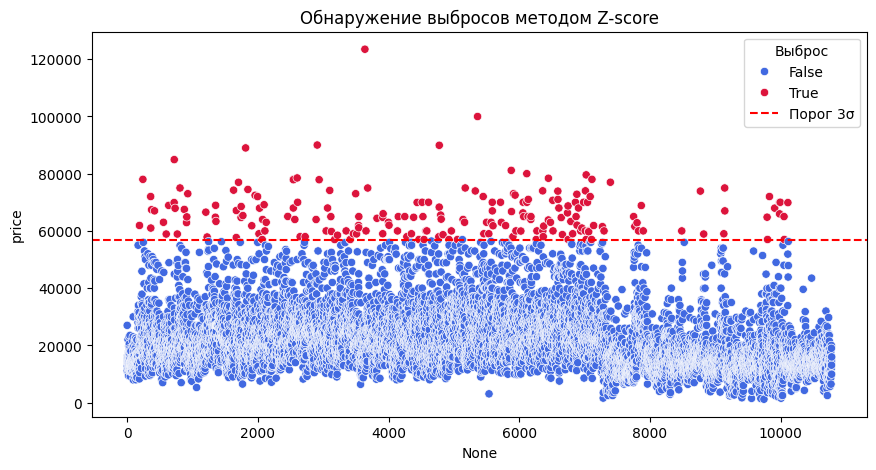

In [36]:

# 1. Расчет Z-оценки
df['price_zscore'] = (df['price'] - df['price'].mean()) / df['price'].std()

# 2. Определение выбросов при |Z| > 3
outliers_z = df[np.abs(df['price_zscore']) > 3]

print(f"Z-оценка: {df['price_zscore'].max():.2f}")

print(f"Количество выбросов (|Z| > 3): {len(outliers_z)}")

# 3. Визуализация
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x=df.index, y='price', hue=np.abs(df['price_zscore']) > 3, 
                palette={False: 'royalblue', True: 'crimson'})
plt.axhline(df['price'].mean() + 3 * df['price'].std(), color='red', linestyle='--', label='Порог 3σ')
plt.title('Обнаружение выбросов методом Z-score')
plt.legend(title='Выброс')
plt.show()

In [37]:
# 1. Расчет квартилей и IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# 2. Определение границ
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Поиск выбросов
outliers_iqr = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Количество выбросов (IQR): {len(outliers_iqr)}")

Q1 (25%): 14950.00
Q3 (75%): 27940.00
IQR: 12990.00
Границы: [-4535.00, 47425.00]
Количество выбросов (IQR): 484


Z-score оказался менее чувствительным. Поскольку распределение цен имеет длинный правый хвост, среднее значение смещено вправо, а стандартное отклонение завышено. Из-за этого метод пропускает многие высокие цены, считая их допустимыми.

IQR идентифицировал значительно больше аномалий. Этот метод лучше подходит для цены на авто , так как он не опирается на предположение о нормальности и четче фиксирует границы типичного ценового сегмента.

### Задание 4. Метрические методы (k-NN)

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Признаки: цена, пробег, налог, расход, объем двигателя
X = df[['price', 'mileage', 'tax', 'mpg', 'engineSize']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
k = 5
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_scaled)
distances, _ = knn.kneighbors(X_scaled)

# Расстояние до k-го соседа (последний столбец)
df['dist_k'] = distances[:, k-1]

# Порог: верхние 5% значений (а=5%)
threshold_k = np.percentile(df['dist_k'], 95)
df['anomaly_dist_k'] = df['dist_k'] > threshold_k

In [54]:
# Вычисляем среднее по строкам (по всем k соседям)
df['avg_dist_k'] = distances.mean(axis=1)

threshold_avg = np.percentile(df['avg_dist_k'], 95)
df['anomaly_avg_dist'] = df['avg_dist_k'] > threshold_avg

In [47]:
df['local_density'] = 1 / df['avg_dist_k']

# Аномалии — это точки с минимальной плотностью (нижние 5%)
threshold_density = np.percentile(df['local_density'], 5)
df['anomaly_density'] = df['local_density'] < threshold_density

In [65]:
# Формирование итогового отчета по аномалиям
methods = ['anomaly_dist_k', 'anomaly_avg_dist', 'anomaly_density']

# Считаем количество аномалий для каждого метода
results = {method: df[method].sum() for method in methods}
print("Количество выявленных аномалий по методам")
for method, count in results.items():
    print(f"{method}: {count} записей")





Количество выявленных аномалий по методам
anomaly_dist_k: 539 записей
anomaly_avg_dist: 539 записей
anomaly_density: 539 записей


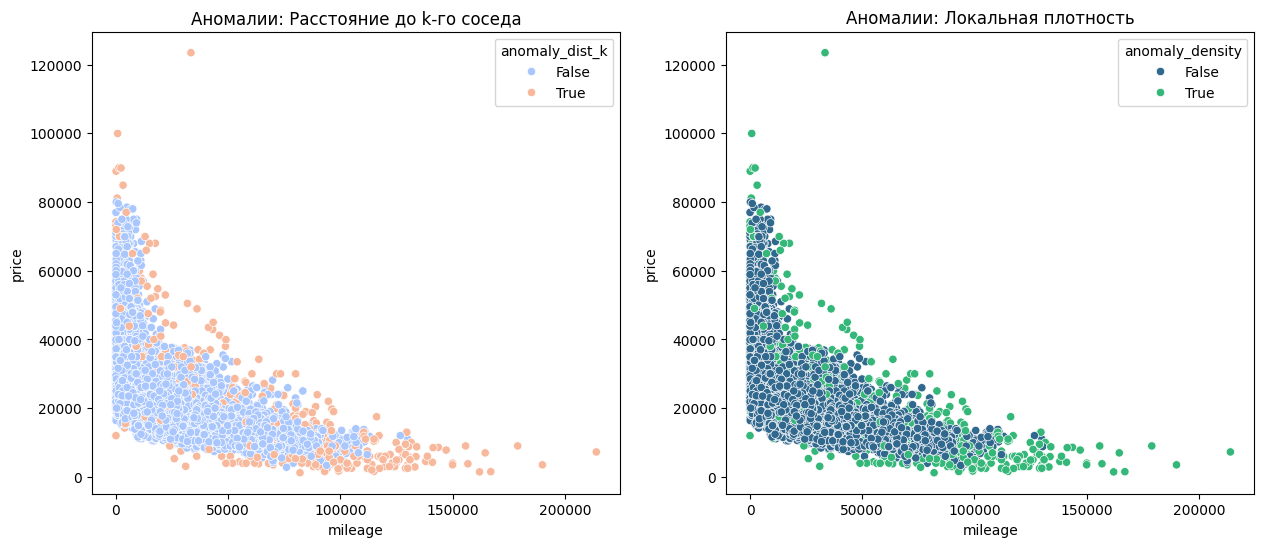

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='mileage', y='price', hue='anomaly_dist_k', ax=axes[0], palette='coolwarm')
axes[0].set_title('Аномалии: Расстояние до k-го соседа')

sns.scatterplot(data=df, x='mileage', y='price', hue='anomaly_density', ax=axes[1], palette='viridis')
axes[1].set_title('Аномалии: Локальная плотность')

plt.show()

 Метрические методы, основанные на оценке локальной плотности, являются наиболее предпочтительными для данного датасета, так как позволяют выявлять не только статистические выбросы, но и логические ошибки в данных, недоступные для одномерных методов (Z-score, IQR).

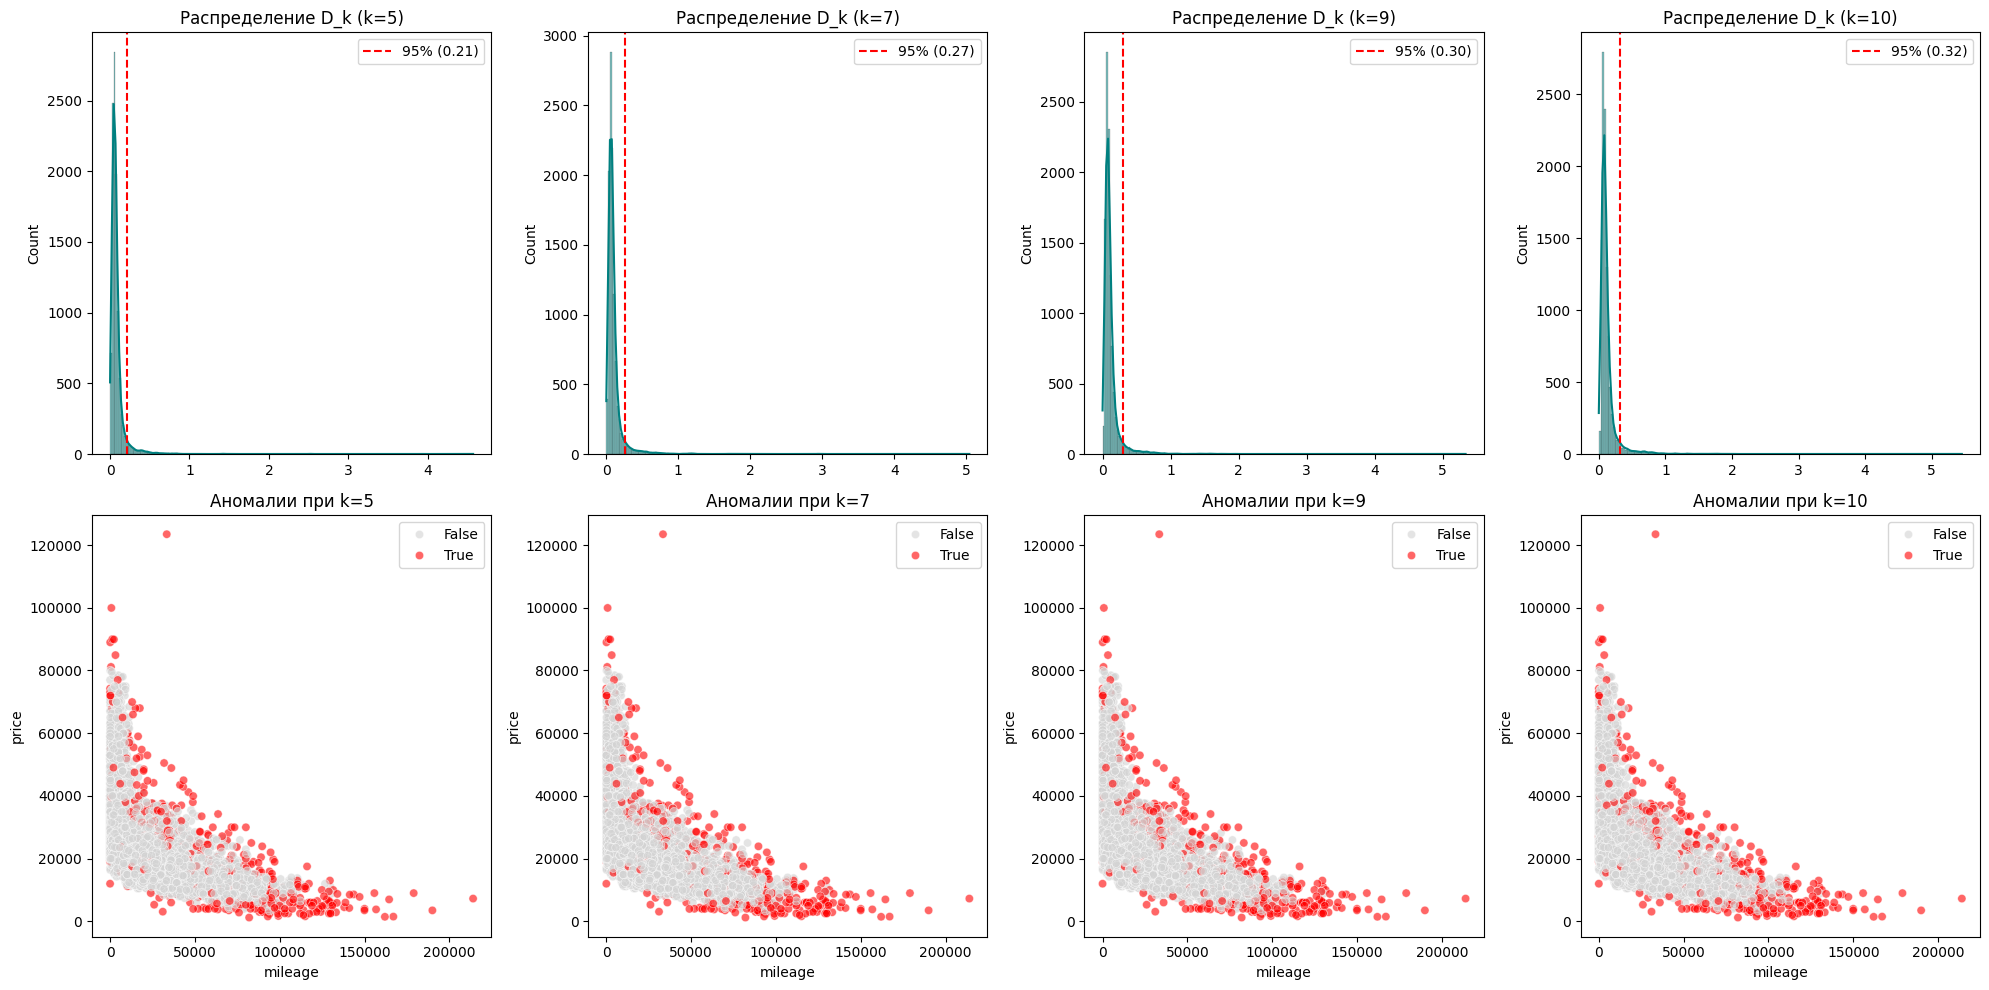

Количество аномалий, выявленных при всех k: 471


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Список значений k для анализа
k_values = [5, 7, 9, 10]
anomaly_indices = {}

# Подготовка графиков (2 ряда по 4 графика: распределение и scatter plot)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, k in enumerate(k_values):
    # 1. Расчет среднего расстояния
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    knn.fit(X_scaled)
    distances, _ = knn.kneighbors(X_scaled)
    avg_dist = distances.mean(axis=1)
    
    # Сохранение метрики в DF для текущего k
    col_name = f'avg_dist_k{k}'
    df[col_name] = avg_dist
    
    # 2. Определение порога (верхние 5%)
    threshold = np.percentile(avg_dist, 95)
    is_anomaly = avg_dist > threshold
    anomaly_indices[k] = set(df[is_anomaly].index)
    
    # 3. Визуализация распределения метрики (верхний ряд)
    sns.histplot(avg_dist, kde=True, ax=axes[0, i], color='teal')
    axes[0, i].axvline(threshold, color='red', linestyle='--', label=f'95% ({threshold:.2f})')
    axes[0, i].set_title(f'Распределение D_k (k={k})')
    axes[0, i].legend()
    
    # 4. Визуализация аномалий на Scatter Plot (нижний ряд)
    sns.scatterplot(data=df, x='mileage', y='price', hue=is_anomaly, 
                    palette={False: 'lightgray', True: 'red'}, ax=axes[1, i], alpha=0.6)
    axes[1, i].set_title(f'Аномалии при k={k}')

plt.tight_layout()
plt.show()

# 5. Количественный анализ пересечений
common_all = set.intersection(*anomaly_indices.values())
print(f"Количество аномалий, выявленных при всех k: {len(common_all)}")

In [67]:
import pandas as pd

stability_matrix = np.zeros((len(k_values), len(k_values)))

for i, k1 in enumerate(k_values):
    for j, k2 in enumerate(k_values):
        intersection = len(anomaly_indices[k1].intersection(anomaly_indices[k2]))
        union = len(anomaly_indices[k1].union(anomaly_indices[k2]))
        stability_matrix[i, j] = intersection / union # Индекс Жаккара

stability_df = pd.DataFrame(stability_matrix, index=k_values, columns=k_values)
print("\nКоэффициенты сходства результатов:")
display(stability_df)


Коэффициенты сходства результатов:


,5,7,9,10
5,1.000000,0.881326,0.811765,0.787728
7,0.881326,1.000000,0.907965,0.874783
9,0.811765,0.907965,1.000000,0.960000
10,0.787728,0.874783,0.960000,1.000000


Распределения метрики среднего расстояния демонстрируют правостороннюю асимметрию, где порог 95-го перцентиля эффективно выделяет изолированные объекты. Визуальный анализ диаграмм рассеяния подтверждает, что при всех значениях k алгоритм стабильно идентифицирует автомобили с аномальными характеристиками цены и пробега. Увеличение k способствует сглаживанию локальных колебаний, что позволяет исключить фоновый шум и сосредоточиться на глобально изолированных записях. Значение k=7 признано оптимальным для данного датасета, обеспечивающим баланс между чувствительностью к выбросам и устойчивостью к вариациям данных.